# Notebook 06 — EDA Condensado y Feature Engineering — Casas Strathclyde

**Proyecto:** PFM MUCSI Deusto — Predicción de Consumo Eléctrico Doméstico  
**Fecha:** 2026-05-06  

## Objetivo
Aplicar un **EDA condensado** y el **feature engineering** (36 features, mismo catálogo que
el Notebook 04) a las casas Strathclyde que superaron el criterio de calidad de datos
(NaN final ≤ 20%) en el Notebook 05.

## Decisión de diseño
Para las casas Strathclyde **no se replica el EDA estadístico completo** (ACF/PACF,
tests ADF/KPSS, descomposición estacional) por las siguientes razones:
1. El EDA completo ya se realizó en el Notebook 04 para Houses 1, 2 y 3, que son
   representativas del dataset REFIT.
2. Los patrones estadísticos fundamentales (estacionalidad diaria, autocorrelación)
   son comunes a todos los hogares del mismo dataset.
3. El objetivo de ampliar el número de hogares es mejorar la **diversidad de perfiles**,
   no replantear el análisis estadístico ya documentado.

Este notebook cubre:
- Estadísticas descriptivas de las casas seleccionadas
- Perfiles de consumo diario y semanal (comparativa entre hogares)
- Feature engineering (36 features idéntico al Nb04)
- Tabla final de selección de hogares para entrenamiento

In [1]:
# ============================================================
# Configuración global
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import gc

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

print(f'pandas   : {pd.__version__}')
print(f'numpy    : {np.__version__}')

# Rutas
DIR_PROCESSED = Path('../datos/processed')
DIR_FIGURAS   = Path('../resultados/figuras')
DIR_METRICAS  = Path('../resultados/metricas')
for d in [DIR_PROCESSED, DIR_FIGURAS, DIR_METRICAS]:
    d.mkdir(parents=True, exist_ok=True)

SEMILLA = 42
UMBRAL_NAN_TRAINING = 20.0  # % NaN máximo para entrenamiento

# Todas las casas Strathclyde (se filtrará por NaN)
CASAS_STRATHCLYDE = [6, 7, 8, 9, 10, 12, 13, 15, 16, 17, 18, 19, 20, 21]

# Festivos UK 2013-2015 (lista manual — sin dependencia de librería externa)
FESTIVOS_UK = pd.to_datetime([
    '2013-12-25', '2013-12-26',
    '2014-01-01', '2014-04-18', '2014-04-21', '2014-05-05',
    '2014-05-26', '2014-08-25', '2014-12-25', '2014-12-26',
    '2015-01-01', '2015-04-03', '2015-04-06', '2015-05-04',
    '2015-05-25', '2015-08-31', '2015-12-25', '2015-12-28'
])

print('Configuración cargada.')

pandas   : 2.2.3
numpy    : 2.0.2
Configuración cargada.


In [2]:
# ============================================================
# Función de feature engineering (36 features, idéntico a Nb04)
# ============================================================

def crear_features(df, columna='Aggregate'):
    """
    Crea el catálogo de 36 features en 5 grupos:
    - 9 temporales: hora, dia_semana, dia_mes, mes, anio, semana_anio,
                    dia_anio, trimestre, parte_dia
    - 3 binarias:   es_fin_semana, es_festivo_uk, es_laboral
    - 8 cíclicas:   sin/cos de hora, dia_semana, mes, dia_anio
    - 8 lags:       lag_1, 5, 15, 30, 60, 120, 1440, 10080 (en minutos)
    - 8 rolling:    media y desv. estándar con ventanas 15, 60, 240, 1440 min
    Total: 36 features
    """
    df_feat = df[[columna]].copy()
    col = df_feat[columna]
    idx = df_feat.index

    # --- 9 Temporales ---
    df_feat['hora']        = idx.hour
    df_feat['dia_semana']  = idx.dayofweek       # 0=Lunes, 6=Domingo
    df_feat['dia_mes']     = idx.day
    df_feat['mes']         = idx.month
    df_feat['anio']        = idx.year
    df_feat['semana_anio'] = idx.isocalendar().week.astype(int)
    df_feat['dia_anio']    = idx.dayofyear
    df_feat['trimestre']   = idx.quarter

    # Parte del día: 0=madrugada(0-5h), 1=mañana(6-11h), 2=tarde(12-17h),
    #               3=vespertino(18-20h), 4=noche(21-23h)
    h = idx.hour
    parte = np.where(h < 6, 0, np.where(h < 12, 1, np.where(h < 18, 2, np.where(h < 21, 3, 4))))
    df_feat['parte_dia'] = parte

    # --- 3 Binarias ---
    df_feat['es_fin_semana']  = (idx.dayofweek >= 5).astype(int)
    df_feat['es_festivo_uk']  = idx.normalize().isin(FESTIVOS_UK).astype(int)
    df_feat['es_laboral']     = (
        (df_feat['es_fin_semana'] == 0) & (df_feat['es_festivo_uk'] == 0)
    ).astype(int)

    # --- 8 Cíclicas (codificación sin/cos para evitar discontinuidades) ---
    df_feat['hora_sin']        = np.sin(2 * np.pi * idx.hour / 24)
    df_feat['hora_cos']        = np.cos(2 * np.pi * idx.hour / 24)
    df_feat['dia_semana_sin']  = np.sin(2 * np.pi * idx.dayofweek / 7)
    df_feat['dia_semana_cos']  = np.cos(2 * np.pi * idx.dayofweek / 7)
    df_feat['mes_sin']         = np.sin(2 * np.pi * idx.month / 12)
    df_feat['mes_cos']         = np.cos(2 * np.pi * idx.month / 12)
    df_feat['dia_anio_sin']    = np.sin(2 * np.pi * idx.dayofyear / 365)
    df_feat['dia_anio_cos']    = np.cos(2 * np.pi * idx.dayofyear / 365)

    # --- 8 Lags (en minutos, índice 1min) ---
    for lag in [1, 5, 15, 30, 60, 120, 1440, 10080]:
        df_feat[f'lag_{lag}'] = col.shift(lag)

    # --- 8 Rolling (media y desv. estándar) ---
    for ventana in [15, 60, 240, 1440]:
        df_feat[f'rolling_mean_{ventana}'] = col.rolling(window=ventana, min_periods=1).mean()
        df_feat[f'rolling_std_{ventana}']  = col.rolling(window=ventana, min_periods=1).std()

    return df_feat


# Verificar que la función genera exactamente 36 features (+1 col objetivo = 37 total)
n_features = 9 + 3 + 8 + 8 + 8  # temporales + binarias + cíclicas + lags + rolling
print(f'Features esperadas: {n_features} (+ columna Aggregate = {n_features + 1} total)')

Features esperadas: 36 (+ columna Aggregate = 37 total)


## 1. Carga de casas procesadas y selección por calidad

In [3]:
# Cargar métricas de limpieza del Nb05 para saber qué casas son aptas
df_metricas_nb05 = pd.read_csv(
    DIR_METRICAS / '05_resumen_limpieza_strathclyde.csv', index_col='house'
)

casas_aptas     = df_metricas_nb05[df_metricas_nb05['apto_training']].index.tolist()
casas_excluidas = df_metricas_nb05[~df_metricas_nb05['apto_training']].index.tolist()

print(f'Casas APTAS para entrenamiento (NaN < {UMBRAL_NAN_TRAINING}%): {casas_aptas}')
print(f'Casas EXCLUIDAS (NaN excesivo):                               {casas_excluidas}')

# Columnas de referencia
cols_ref = ['pct_nan_final', 'media_limpio_w', 'max_limpio_w', 'dias']
print('\nResumen de casas aptas:')
print(df_metricas_nb05.loc[casas_aptas, cols_ref].to_string())

Casas APTAS para entrenamiento (NaN < 20.0%): [6, 7, 8, 9, 10, 12, 15, 16, 17, 18, 19, 20, 21]
Casas EXCLUIDAS (NaN excesivo):                               [13]

Resumen de casas aptas:
       pct_nan_final  media_limpio_w  max_limpio_w  dias
house                                                   
6              14.71           480.4        8121.2   577
7              12.20           562.0       11069.9   613
8               9.89           681.9       14870.0   555
9              15.08           575.6       13776.6   568
10              8.94           759.5        9643.1   586
12              6.21           371.0        8779.3   487
15             11.72           255.3        8662.0   567
16             15.31           556.8       11453.0   543
17              5.75           406.3       13004.0   469
18              5.63           446.8       11553.6   443
19              5.75           291.0        7571.2   470
20              5.79           375.9        7321.1   460
21             

In [4]:
# Cargar datos limpios de casas aptas
datos = {}
stats_desc = []

for numero in casas_aptas:
    ruta = DIR_PROCESSED / f'house{numero}_1min_limpio.csv'
    df = pd.read_csv(ruta, index_col='Time', parse_dates=True)
    datos[numero] = df
    
    agg = df['Aggregate'].dropna()
    stats_desc.append({
        'house'      : numero,
        'n_registros': len(df),
        'inicio'     : df.index.min().strftime('%Y-%m-%d'),
        'fin'        : df.index.max().strftime('%Y-%m-%d'),
        'media_w'    : round(agg.mean(), 1),
        'mediana_w'  : round(agg.median(), 1),
        'std_w'      : round(agg.std(), 1),
        'p25_w'      : round(agg.quantile(0.25), 1),
        'p75_w'      : round(agg.quantile(0.75), 1),
        'max_w'      : round(agg.max(), 1),
        'asimetria'  : round(agg.skew(), 3),
        'curtosis'   : round(agg.kurt(), 3),
        'pct_nan'    : round(100 * df['Aggregate'].isna().mean(), 2)
    })
    print(f'House {numero} cargada: {len(df):,} filas | media={agg.mean():.0f}W')

df_desc = pd.DataFrame(stats_desc).set_index('house')
print('\nCarga completada.')

House 6 cargada: 831,420 filas | media=480W


House 7 cargada: 882,910 filas | media=562W


House 8 cargada: 799,224 filas | media=682W


House 9 cargada: 817,947 filas | media=576W


House 10 cargada: 845,197 filas | media=759W


...

House 17 cargada: 676,650 filas | media=406W


House 18 cargada: 637,922 filas | media=447W


House 19 cargada: 677,410 filas | media=291W


House 20 cargada: 662,804 filas | media=376W


House 21 cargada: 705,337 filas | media=638W

Carga completada.


## 2. Estadísticas descriptivas comparativas

In [5]:
print('Estadísticas descriptivas — casas Strathclyde aptas para entrenamiento')
print('=' * 80)
print(df_desc.to_string())
print(f'\nNota: asimetría > 3 → distribución muy asimétrica (cola derecha)')
print(f'      curtosis > 3  → distribución leptocúrtica (colas pesadas)')

Estadísticas descriptivas — casas Strathclyde aptas para entrenamiento
       n_registros      inicio         fin  media_w  mediana_w   std_w  p25_w  p75_w    max_w  asimetria  curtosis  pct_nan
house                                                                                                                      
6           831420  2013-11-28  2015-06-28    480.4      369.7   427.3  258.2  555.9   8121.2      4.727    29.113    14.71
7           882910  2013-11-01  2015-07-08    562.0      226.9   808.7  162.0  558.7  11069.9      3.092    11.559    12.20
8           799224  2013-11-01  2015-05-10    681.9      261.8  1096.0  203.8  748.2  14870.0      5.269    42.753     9.89
9           817947  2013-12-17  2015-07-08    575.6      208.7   933.5  171.6  560.2  13776.6      4.556    29.219    15.08
10          845197  2013-11-20  2015-06-30    759.5      432.8   833.3  269.4  793.2   9643.1      2.506     7.789     8.94
12          702139  2014-03-07  2015-07-08    371.0      169.

## 3. Perfiles de consumo diario y semanal

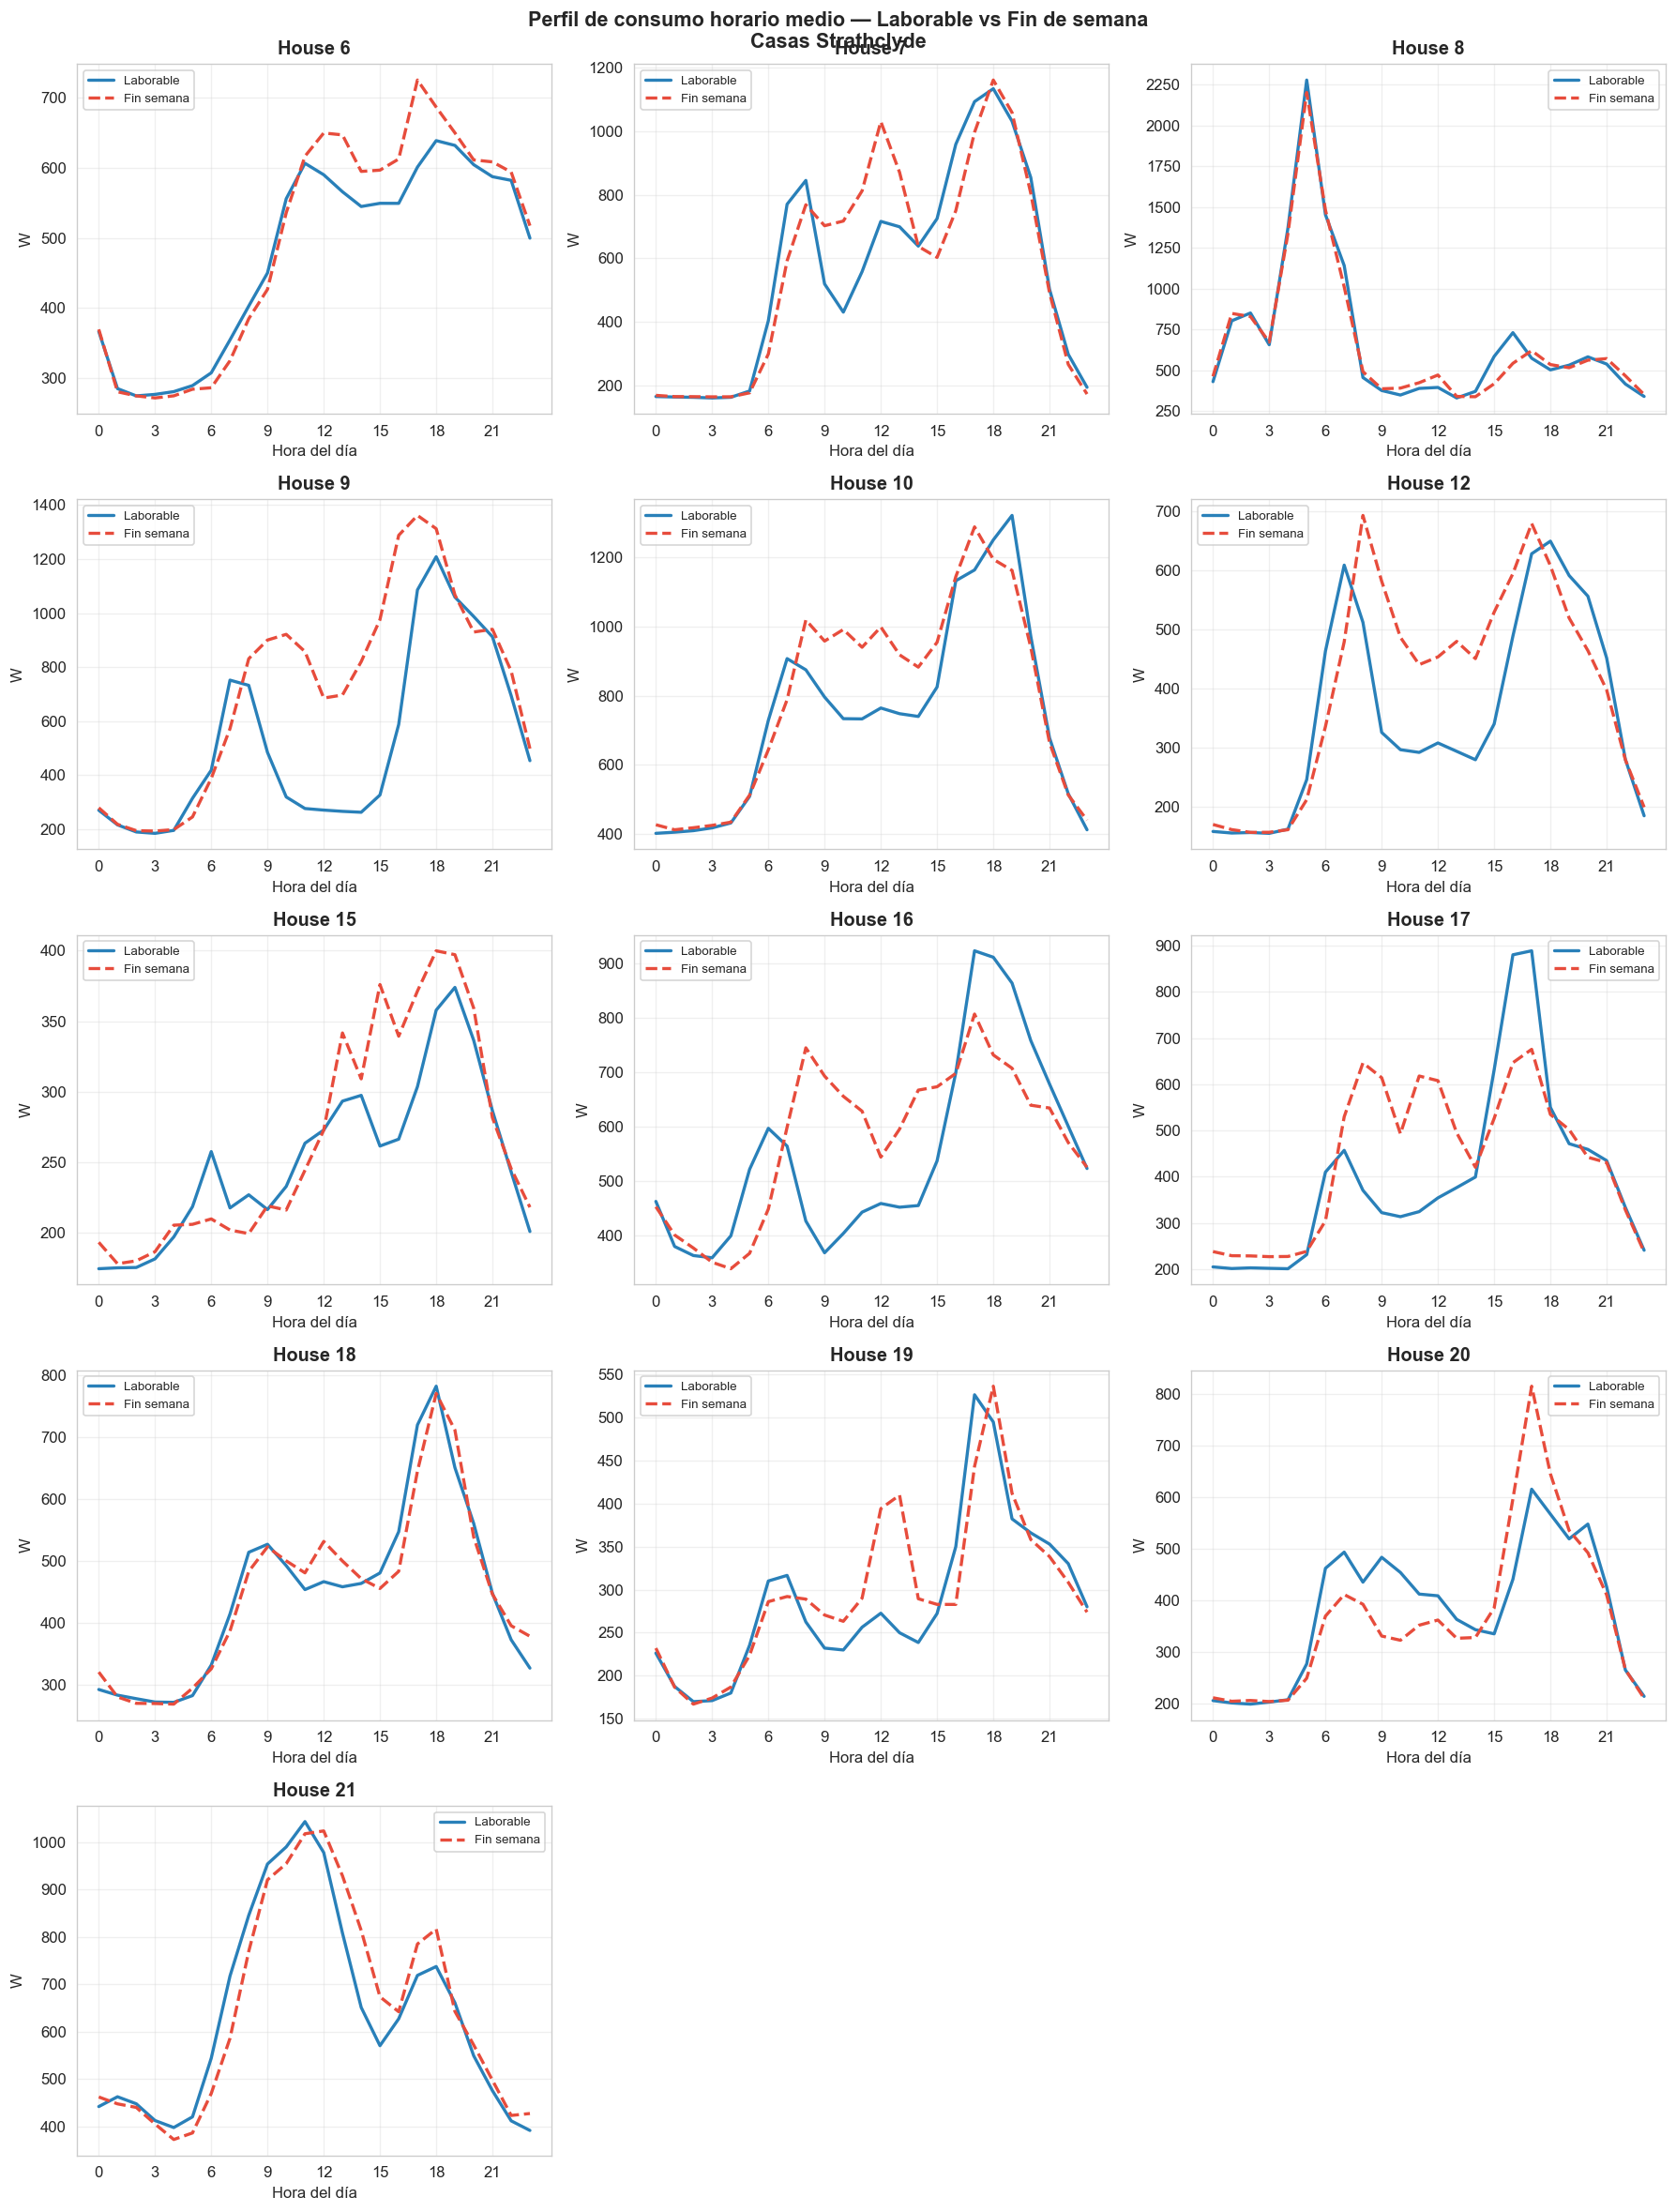

Figura guardada: 06_perfil_diario_strathclyde.png


In [6]:
# Perfil horario medio por hogar (laborables vs fines de semana)
n_casas = len(casas_aptas)
ncols_fig = min(3, n_casas)
nfilas_fig = (n_casas + ncols_fig - 1) // ncols_fig

fig, axes = plt.subplots(nfilas_fig, ncols_fig, figsize=(5 * ncols_fig, 4 * nfilas_fig))
axes_flat = axes.flatten() if n_casas > 1 else [axes]

for i, numero in enumerate(casas_aptas):
    df = datos[numero].copy()
    df['hora'] = df.index.hour
    df['es_fin_semana'] = (df.index.dayofweek >= 5)
    
    laborable = df[~df['es_fin_semana']].groupby('hora')['Aggregate'].mean()
    finde     = df[df['es_fin_semana']].groupby('hora')['Aggregate'].mean()
    
    ax = axes_flat[i]
    ax.plot(laborable.index, laborable.values, label='Laborable', color='#2980b9', linewidth=2)
    ax.plot(finde.index,     finde.values,     label='Fin semana', color='#e74c3c', linewidth=2, linestyle='--')
    ax.set_title(f'House {numero}', fontweight='bold')
    ax.set_xlabel('Hora del día')
    ax.set_ylabel('W')
    ax.set_xticks(range(0, 24, 3))
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Ocultar ejes vacíos
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('Perfil de consumo horario medio — Laborable vs Fin de semana\nCasas Strathclyde',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(DIR_FIGURAS / '06_perfil_diario_strathclyde.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: 06_perfil_diario_strathclyde.png')

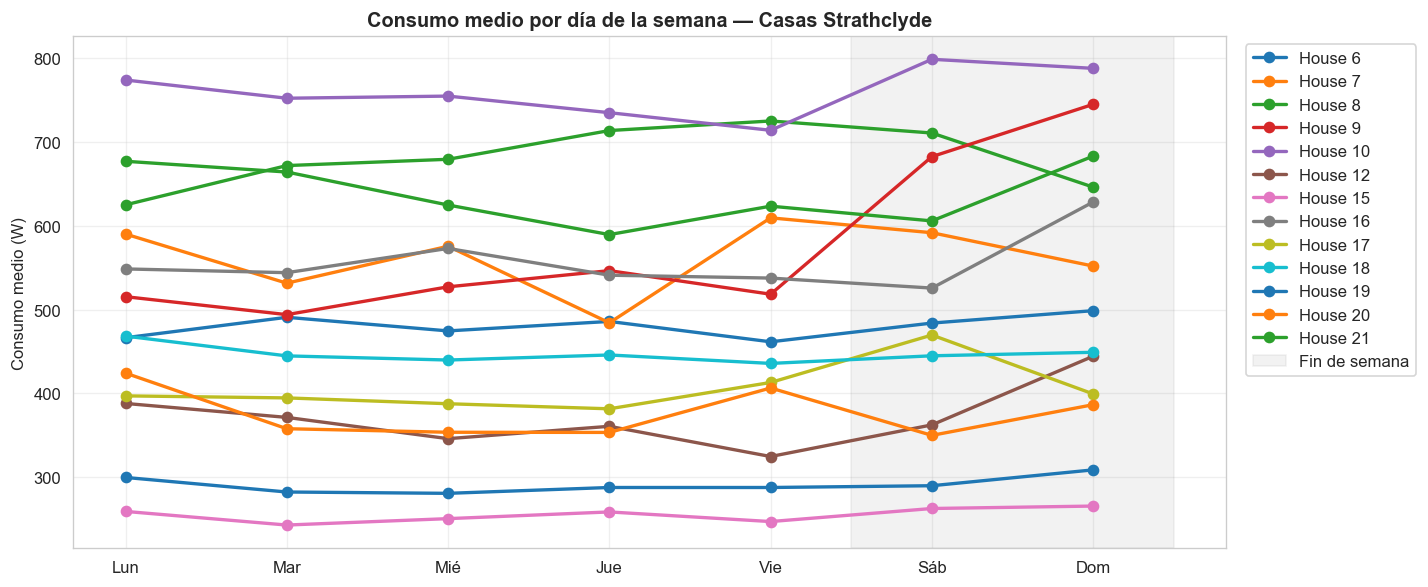

Figura guardada: 06_perfil_semanal_strathclyde.png


In [7]:
# Perfil semanal — consumo medio por día de la semana (todos los hogares en un gráfico)
dias_semana = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']

fig, ax = plt.subplots(figsize=(12, 5))
colores = sns.color_palette('tab10', n_colors=n_casas)

for i, numero in enumerate(casas_aptas):
    df = datos[numero].copy()
    df['dia_semana'] = df.index.dayofweek
    perfil = df.groupby('dia_semana')['Aggregate'].mean()
    ax.plot(perfil.index, perfil.values, marker='o', linewidth=2,
            color=colores[i], label=f'House {numero}')

ax.set_xticks(range(7))
ax.set_xticklabels(dias_semana)
ax.axvspan(4.5, 6.5, alpha=0.1, color='gray', label='Fin de semana')
ax.set_title('Consumo medio por día de la semana — Casas Strathclyde', fontweight='bold')
ax.set_ylabel('Consumo medio (W)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(DIR_FIGURAS / '06_perfil_semanal_strathclyde.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: 06_perfil_semanal_strathclyde.png')

## 4. Feature Engineering (36 features)
Aplicamos el catálogo unificado de features a cada casa apta. Los ficheros resultantes
se guardan en `datos/processed/` con el mismo formato que los generados en el Notebook 04.

In [8]:
# Feature engineering — loop sobre casas aptas
stats_features = []

for numero in casas_aptas:
    print(f'Generando features para House {numero}...', end=' ')
    
    df = datos[numero].copy()
    df_feat = crear_features(df, columna='Aggregate')
    
    # Estadísticas de NaN en features
    n_total = len(df_feat)
    nan_por_feature = df_feat.isna().sum()
    
    # Correlación de features con Aggregate
    df_completo = df_feat.dropna(subset=['Aggregate'])
    corr_agg = df_completo.corr()['Aggregate'].drop('Aggregate').abs().sort_values(ascending=False)
    top5 = corr_agg.head(5)
    
    stats_features.append({
        'house'         : numero,
        'n_registros'   : n_total,
        'n_features'    : len(df_feat.columns) - 1,  # -1 por Aggregate
        'nan_lag_10080' : int(nan_por_feature.get('lag_10080', 0)),  # lag 7 días genera NaN iniciales
        'top1_feature'  : top5.index[0] if len(top5) > 0 else '-',
        'top1_corr'     : round(top5.iloc[0], 3) if len(top5) > 0 else 0,
        'top2_feature'  : top5.index[1] if len(top5) > 1 else '-',
        'top2_corr'     : round(top5.iloc[1], 3) if len(top5) > 1 else 0,
    })
    
    # Guardar features a disco
    ruta_out = DIR_PROCESSED / f'house{numero}_features.csv'
    df_feat.to_csv(ruta_out)
    print(f'{len(df_feat):,} filas | top feat: {top5.index[0]} (r={top5.iloc[0]:.3f})')
    
    del df_feat, df_completo
    gc.collect()

df_stats_features = pd.DataFrame(stats_features).set_index('house')
print('\nFeature engineering completado.')

Generando features para House 6... 

831,420 filas | top feat: lag_1 (r=0.779)
Generando features para House 7... 

882,910 filas | top feat: lag_1 (r=0.924)
Generando features para House 8... 

799,224 filas | top feat: lag_1 (r=0.878)
Generando features para House 9... 

817,947 filas | top feat: lag_1 (r=0.913)
Generando features para House 10... 

...

676,650 filas | top feat: lag_1 (r=0.857)
Generando features para House 18... 

637,922 filas | top feat: lag_1 (r=0.915)
Generando features para House 19... 

677,410 filas | top feat: lag_1 (r=0.786)
Generando features para House 20... 

662,804 filas | top feat: lag_1 (r=0.805)
Generando features para House 21... 

705,337 filas | top feat: lag_1 (r=0.936)

Feature engineering completado.


In [9]:
print('Resumen de features generadas — casas Strathclyde aptas')
print('=' * 70)
print(df_stats_features.to_string())
print(f'\nNota: nan_lag_10080 = primeras 10.080 filas con NaN en lag semanal')
print(f'      Estrategia: eliminar primeras 10.080 filas antes de entrenar (mismo criterio Nb04)')

Resumen de features generadas — casas Strathclyde aptas
       n_registros  n_features  nan_lag_10080 top1_feature  top1_corr     top2_feature  top2_corr
house                                                                                            
6           831420          36         132406        lag_1      0.779  rolling_mean_15      0.671
7           882910          36         117801        lag_1      0.924  rolling_mean_15      0.794
8           799224          36          89150        lag_1      0.878  rolling_mean_15      0.706
9           817947          36         133351        lag_1      0.913  rolling_mean_15      0.763
10          845197          36          85674        lag_1      0.922  rolling_mean_15      0.857
12          702139          36          53673        lag_1      0.893  rolling_mean_15      0.718
15          816947          36         105815        lag_1      0.876  rolling_mean_15      0.761
16          782773          36         129945        lag_1    

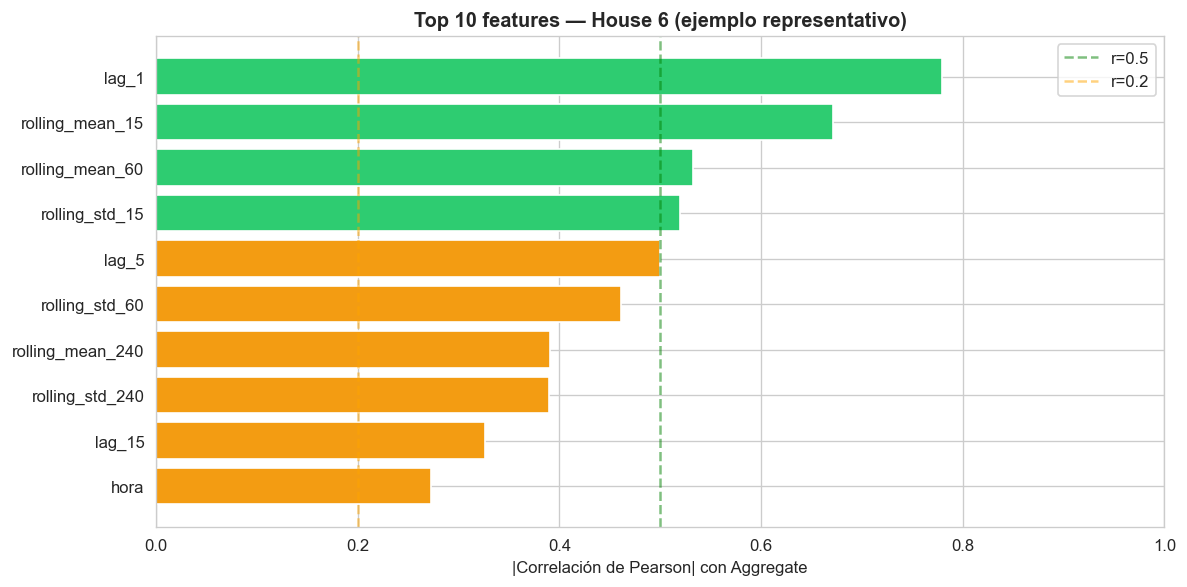

Figura guardada: 06_features_correlacion_strathclyde.png


In [10]:
# Figura: Top 10 features más correlacionadas con Aggregate (primera casa como ejemplo)
if casas_aptas:
    numero_ejemplo = casas_aptas[0]
    ruta_feat = DIR_PROCESSED / f'house{numero_ejemplo}_features.csv'
    df_ej = pd.read_csv(ruta_feat, index_col='Time', parse_dates=True).dropna(subset=['Aggregate'])
    
    corr_ej = df_ej.corr()['Aggregate'].drop('Aggregate').abs().sort_values(ascending=False)
    top10 = corr_ej.head(10)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    colores_barra = ['#2ecc71' if v > 0.5 else '#f39c12' if v > 0.2 else '#bdc3c7' for v in top10.values]
    ax.barh(range(len(top10)), top10.values, color=colores_barra)
    ax.set_yticks(range(len(top10)))
    ax.set_yticklabels(top10.index)
    ax.invert_yaxis()
    ax.axvline(0.5, color='green', linestyle='--', alpha=0.5, label='r=0.5')
    ax.axvline(0.2, color='orange', linestyle='--', alpha=0.5, label='r=0.2')
    ax.set_xlabel('|Correlación de Pearson| con Aggregate')
    ax.set_title(f'Top 10 features — House {numero_ejemplo} (ejemplo representativo)', fontweight='bold')
    ax.legend()
    ax.set_xlim(0, 1)
    plt.tight_layout()
    plt.savefig(DIR_FIGURAS / '06_features_correlacion_strathclyde.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figura guardada: 06_features_correlacion_strathclyde.png')
    del df_ej
    gc.collect()

## 5. Tabla final de selección de hogares para modelado

In [11]:
# Tabla consolidada: todos los hogares del proyecto

# Hogares Zenodo (Nb03/Nb04)
zenodo_houses = [
    {'house': 1,  'fuente': 'Zenodo CLEAN', 'pct_nan': 12.03, 'uso': 'Entrenamiento'},
    {'house': 2,  'fuente': 'Zenodo CLEAN', 'pct_nan': 23.69, 'uso': 'Validación externa'},
    {'house': 3,  'fuente': 'Zenodo CLEAN', 'pct_nan': 12.43, 'uso': 'Entrenamiento'},
    {'house': 4,  'fuente': 'Zenodo CLEAN', 'pct_nan': None,  'uso': 'Entrenamiento'},
    {'house': 5,  'fuente': 'Zenodo CLEAN', 'pct_nan': None,  'uso': 'Entrenamiento'},
    {'house': 11, 'fuente': 'Zenodo CLEAN', 'pct_nan': None,  'uso': 'Entrenamiento'},
]

# Hogares Strathclyde (este notebook)
strathclyde_rows = []
for _, row in df_metricas_nb05.iterrows():
    uso = 'Entrenamiento' if row['apto_training'] else 'Excluido (NaN)'
    strathclyde_rows.append({
        'house'   : int(row.name),
        'fuente'  : 'Strathclyde',
        'pct_nan' : row['pct_nan_final'],
        'uso'     : uso
    })

df_seleccion = pd.DataFrame(zenodo_houses + strathclyde_rows).set_index('house').sort_index()

print('Tabla final de selección de hogares — PFM MUCSI Deusto')
print('=' * 65)
print(df_seleccion.to_string())

n_train = (df_seleccion['uso'] == 'Entrenamiento').sum()
n_val   = (df_seleccion['uso'] == 'Validación externa').sum()
n_excl  = (df_seleccion['uso'] == 'Excluido (NaN)').sum()
print(f'\nResumen:')
print(f'  Hogares para entrenamiento  : {n_train}')
print(f'  Hogares para validación ext.: {n_val}')
print(f'  Hogares excluidos           : {n_excl}')

Tabla final de selección de hogares — PFM MUCSI Deusto
             fuente  pct_nan                 uso
house                                           
1      Zenodo CLEAN    12.03       Entrenamiento
2      Zenodo CLEAN    23.69  Validación externa
3      Zenodo CLEAN    12.43       Entrenamiento
4      Zenodo CLEAN      NaN       Entrenamiento
5      Zenodo CLEAN      NaN       Entrenamiento
6       Strathclyde    14.71       Entrenamiento
7       Strathclyde    12.20       Entrenamiento
8       Strathclyde     9.89       Entrenamiento
9       Strathclyde    15.08       Entrenamiento
10      Strathclyde     8.94       Entrenamiento
11     Zenodo CLEAN      NaN       Entrenamiento
12      Strathclyde     6.21       Entrenamiento
13      Strathclyde    21.27      Excluido (NaN)
15      Strathclyde    11.72       Entrenamiento
16      Strathclyde    15.31       Entrenamiento
17      Strathclyde     5.75       Entrenamiento
18      Strathclyde     5.63       Entrenamiento
19      Strath

In [12]:
# Guardar tablas de resultados
df_desc.to_csv(DIR_METRICAS / '06_estadisticos_strathclyde.csv')
df_stats_features.to_csv(DIR_METRICAS / '06_features_correlacion_strathclyde.csv')
df_seleccion.to_csv(DIR_METRICAS / '06_seleccion_hogares_final.csv')
print('CSVs guardados en resultados/metricas/')
print('  - 06_estadisticos_strathclyde.csv')
print('  - 06_features_correlacion_strathclyde.csv')
print('  - 06_seleccion_hogares_final.csv')

CSVs guardados en resultados/metricas/
  - 06_estadisticos_strathclyde.csv
  - 06_features_correlacion_strathclyde.csv
  - 06_seleccion_hogares_final.csv


## 6. Conclusiones

### Homogeneidad del catálogo de features
Las 36 features aplicadas a las casas Strathclyde son **idénticas** a las del Notebook 04,
garantizando un catálogo unificado para todos los modelos de predicción.

### Consistencia de patrones
Los perfiles de consumo diario y semanal confirman que los patrones observados en
Houses 1-5 y 11 se reproducen en las nuevas casas, con variaciones propias de cada
perfil de hogar (número de ocupantes, horarios de ocupación).

### Estrategia NaN en modelado
Al igual que en el Notebook 04, las primeras 10.080 filas de cada casa (correspondientes
al lag semanal `lag_10080`) contienen NaN propagados. **Se eliminarán antes del entrenamiento.**

### Archivos generados
- `datos/processed/house{N}_1min_limpio.csv` — datos limpios (1 min)
- `datos/processed/house{N}_features.csv` — 36 features + Aggregate
- `resultados/metricas/06_estadisticos_strathclyde.csv`
- `resultados/metricas/06_features_correlacion_strathclyde.csv`
- `resultados/metricas/06_seleccion_hogares_final.csv`
- `resultados/figuras/06_perfil_diario_strathclyde.png`
- `resultados/figuras/06_perfil_semanal_strathclyde.png`
- `resultados/figuras/06_features_correlacion_strathclyde.png`

**Siguiente paso:** Notebook 07 — Modelado baseline (media histórica, última observación conocida)